In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib, os, warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet("../data/churn_frame.parquet")
TARGET = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

print(f"Loaded: {df.shape}")

Loaded: (8000, 25)


In [2]:
# FIX: Convert category dtype to string for sklearn compatibility
for col in ["plan_tier", "region", "is_autopay", "is_discounted", "has_family_bundle"]:
    df[col] = df[col].astype(str)

print("✅ Dtypes fixed!")
print(df[["plan_tier", "region", "is_autopay"]].dtypes)

✅ Dtypes fixed!
plan_tier     object
region        object
is_autopay    object
dtype: object


In [3]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add engineered business features.
    
    All features use only data available at prediction time (end of cycle T).
    Small epsilon (1e-3) prevents division by zero.
    """
    df = df.copy()
    
    # Engagement quality: fraction of month the customer was active
    df["engagement_rate"] = (df["active_days"] / 30.0).clip(0, 1)
    
    # Session depth: usage hours per login session
    df["usage_per_login"] = df["monthly_usage_hours"] / (df["login_count"] + 1e-3)
    
    # Support stress: tickets + 3x penalty for SLA breaches
    df["support_intensity"] = df["support_tickets"] + 3 * df["sla_breaches"]
    
    # Email engagement: click-through rate
    df["email_ctr"] = df["email_clicks"] / (df["email_opens"] + 1e-3)
    
    # Price sensitivity: billing relative to tenure (high = potentially overpriced for loyalty)
    df["price_to_tenure"] = df["billing_amount"] / (df["tenure_months"] + 1e-3)
    
    return df

df = add_features(df)
print("✅ Added 5 engineered features")
print("\nNew features summary:")
new_feats = ["engagement_rate","usage_per_login","support_intensity","email_ctr","price_to_tenure"]
print(df[new_feats].describe().round(3).to_string())

✅ Added 5 engineered features

New features summary:
       engagement_rate  usage_per_login  support_intensity  email_ctr  price_to_tenure
count         8000.000         8000.000           8000.000   8000.000         8000.000
mean             0.649            2.207              1.416      0.156           86.285
std              0.086            1.580              1.630      0.179          149.646
min              0.333            0.048              0.000      0.000            2.059
25%              0.600            1.146              0.000      0.000           14.263
50%              0.633            1.822              1.000      0.000           31.501
75%              0.700            2.841              2.000      0.333           81.270
max              0.933           21.004             15.000      0.500         1055.425


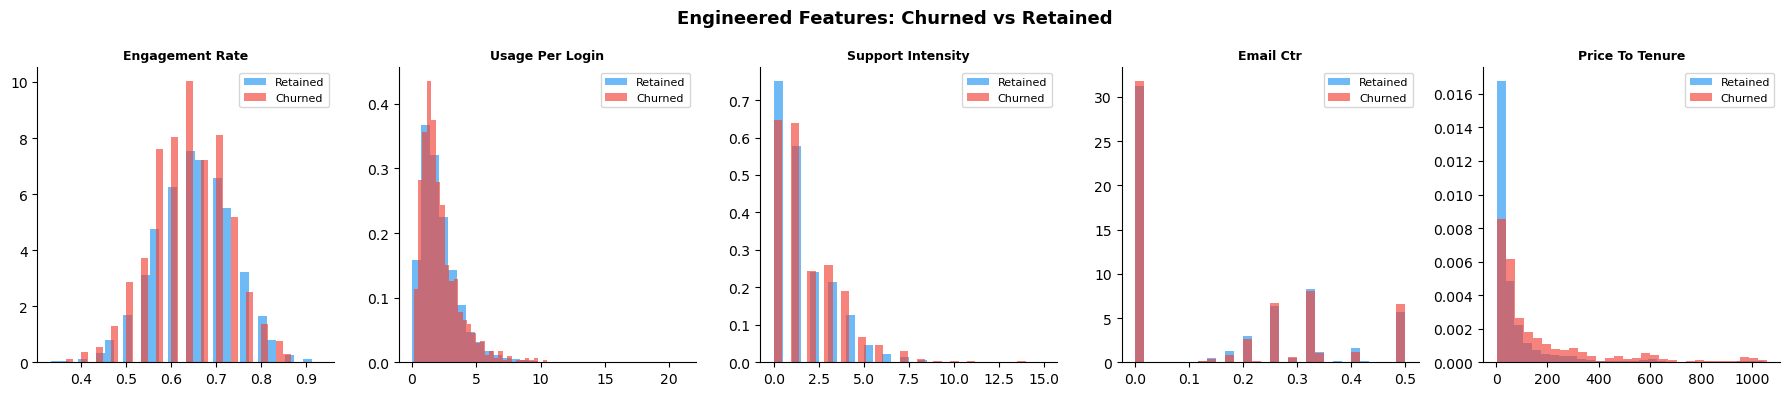

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Engineered Features: Churned vs Retained", fontsize=13, fontweight='bold')

new_feats = ["engagement_rate","usage_per_login","support_intensity","email_ctr","price_to_tenure"]
colors = {0: "#2196F3", 1: "#F44336"}
labels = {0: "Retained", 1: "Churned"}

for ax, feat in zip(axes, new_feats):
    for cls in [0, 1]:
        ax.hist(df[df[TARGET]==cls][feat].dropna(),
                bins=30, alpha=0.65, color=colors[cls], label=labels[cls],
                density=True, edgecolor='none')
    ax.set_title(feat.replace("_"," ").title(), fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("../data/engineered_features.png", dpi=120, bbox_inches='tight')
plt.show()

In [5]:
# ── Define feature groups ─────────────────────────────────────────────────
NUM_FEATS = [
    "billing_amount","last_payment_days_ago","tenure_months",
    "monthly_usage_hours","active_days","login_count","avg_session_min",
    "device_count","add_on_count","support_tickets","sla_breaches",
    "promotions_redeemed","email_opens","email_clicks","last_campaign_days_ago",
    "nps_score",
    # engineered
    "engagement_rate","usage_per_login","support_intensity","email_ctr","price_to_tenure",
]

CAT_FEATS = ["plan_tier","region","is_autopay","is_discounted","has_family_bundle"]

print(f"Numeric features:     {len(NUM_FEATS)}")
print(f"Categorical features: {len(CAT_FEATS)}")
print(f"Total:                {len(NUM_FEATS)+len(CAT_FEATS)}")

Numeric features:     21
Categorical features: 5
Total:                26


In [6]:
# ── Build sklearn pipelines ───────────────────────────────────────────────
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, NUM_FEATS),
    ("cat", cat_pipeline, CAT_FEATS),
], remainder="drop")

print("✅ ColumnTransformer built")
print("\nPipeline structure:")
print("  numeric  →  SimpleImputer(median)  →  StandardScaler")
print("  categorical →  SimpleImputer(most_frequent) →  OneHotEncoder")

✅ ColumnTransformer built

Pipeline structure:
  numeric  →  SimpleImputer(median)  →  StandardScaler
  categorical →  SimpleImputer(most_frequent) →  OneHotEncoder


In [7]:
# Fit on full dataset to verify pipeline works end-to-end
X = df.drop(columns=EXCLUDE)
y = df[TARGET]

preprocessor.fit(X, y)
X_transformed = preprocessor.transform(X)

print(f"Input shape:  {X.shape}")
print(f"Output shape: {X_transformed.shape}")
print(f"\n✅ Pipeline transforms {X.shape[1]} → {X_transformed.shape[1]} features (after OHE expansion)")

Input shape:  (8000, 26)
Output shape: (8000, 35)

✅ Pipeline transforms 26 → 35 features (after OHE expansion)


In [8]:
os.makedirs("../models", exist_ok=True)

joblib.dump(preprocessor, "../models/preprocessor.joblib")
joblib.dump({"NUM_FEATS": NUM_FEATS, "CAT_FEATS": CAT_FEATS}, "../models/feature_config.joblib")

print("✅ Saved:")
print("   ../models/preprocessor.joblib")
print("   ../models/feature_config.joblib")

✅ Saved:
   ../models/preprocessor.joblib
   ../models/feature_config.joblib
